In [2]:
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import h5py

In [3]:
f = h5py.File("GrmhdTovStarLev2Reduction.h5")
max_data = np.array(f['max_data.dat'])
time_steps = np.array(f['time_steps.dat'])

In [4]:
max_data.shape

(4001, 4)

In [5]:
header = dict(f['max_data.dat'].attrs)['Legend']
header

array(['Time', 'NumberOfPoints', 'Volume', 'Max(RestMassDensity)'],
      dtype=object)

Text(0.5, 0, 'time ($\\mathrm{ms}$)')

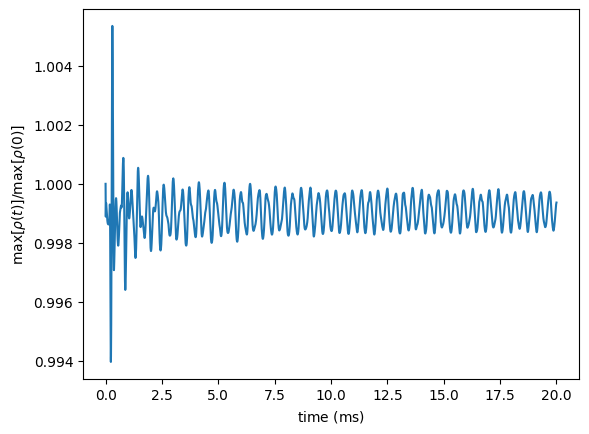

In [6]:
# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['savefig.dpi'] = 300

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(max_data[:,0]/200,max_data[:,3]/max_data[0,3])
ax.set_ylabel(r"$\mathrm{max}[\rho(t)]/\mathrm{max}[\rho(0)]$")
ax.set_xlabel("time ($\mathrm{ms}$)")

In [7]:
fft_vals = np.fft.fft(max_data[:,3])
power_spectrum = np.abs(fft_vals)**2

# Frequency axis
freqs = np.fft.fftfreq(len(max_data[:,3]), d=0.000005)/1000  # d = sampling interval, in units of kHz

# Only keep positive frequencies
mask = freqs >= 0

(1e-11, 0.001)

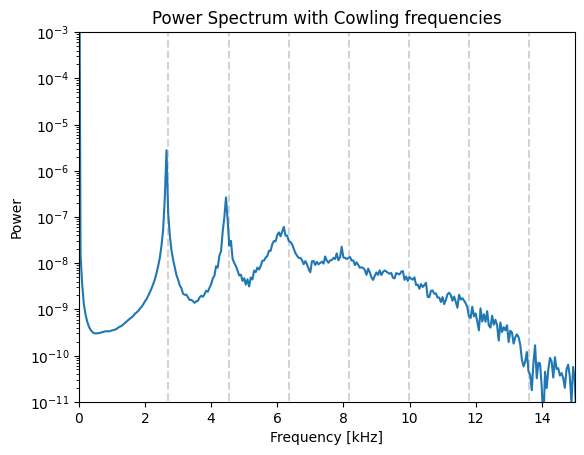

In [8]:
# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['savefig.dpi'] = 300

fig = plt.figure()
ax = fig.add_subplot(111)
ax.vlines([2.696, 4.534, 6.346, 8.161, 9.971, 11.806, 13.603],0,1,color='lightgray',ls='--')
ax.plot(freqs[mask], power_spectrum[mask])
ax.set_xlabel('Frequency [kHz]')
ax.set_ylabel('Power')
ax.set_title('Power Spectrum with Cowling frequencies')
ax.set_yscale('log')
ax.set_xlim(0,15)
ax.set_ylim(1e-11,1e-3)